In [1]:
print("Hello")

Hello


In [2]:
!pip install sigpy

   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ------- -------------------------------- 0.5/2.8 MB 3.4 MB/s eta 0:00:01
   ---------------------- ----------------- 1.6/2.8 MB 4.2 MB/s eta 0:00:01
   ------------------------------------- -- 2.6/2.8 MB 4.7 MB/s eta 0:00:01
   ---------------------------------------- 2.8/2.8 MB 4.1 MB/s  0:00:00
   ---------------------------------------- 0.0/41.9 MB ? eta -:--:--
   - -------------------------------------- 1.6/41.9 MB 8.3 MB/s eta 0:00:05
   --- ------------------------------------ 3.7/41.9 MB 9.1 MB/s eta 0:00:05
   ----- ---------------------------------- 5.5/41.9 MB 9.1 MB/s eta 0:00:05
   ------- -------------------------------- 7.3/41.9 MB 8.9 MB/s eta 0:00:04
   -------- ------------------------------- 9.2/41.9 MB 8.8 MB/s eta 0:00:04
   ---------- ----------------------------- 10.5/41.9 MB 8.4 MB/s eta 0:00:04
   ----------- ---------------------------- 12.3/41.9 MB 8.2 MB/s eta 0:00:04
   ------------ ---

In [2]:
import sigpy
import SimpleITK as sitk
import numpy as np 
import matplotlib.pyplot as plt

c:\Users\Ines\anaconda3\envs\3d-mri\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [37]:
from sigpy.mri import samp
import time

In [7]:
sigpy.__version__

'0.1.27'

In [8]:
sitk_t1 = sitk.ReadImage("t1.nii.gz") 
t1 = sitk.GetArrayFromImage(sitk_t1) 

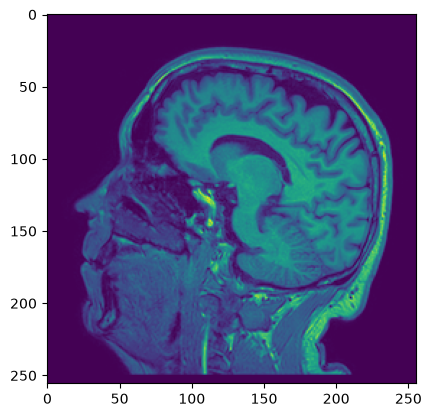

In [9]:
plt.imshow(t1[50])

Simulation of radial sampling: (15%) 
Use sigpy.mri.radial(coord_shape, img_shape) to generate the coordinates in the k
space. coord_shape is a vector with [number of spokes, number of acquisitions per spoke, 
dimension]. Img_shape is the dimension of the image. In the project, we are interested in 
testing different values of “number of spokes” so you can call the method as: 
coord = sigpy.mri.radial([spokes,256,2],[256,256]) 
One “spoke” is depicted in red in the figure. 256 samples of the k-space are acquired per 
spoke. The spokes are equally distributed in the circle. As mentioned, the image size is 
256x256 in plane and 90 slices. WARNING!: To ease the problem, don’t use the golden angle 
ordering provided by the library. 
We will use these coordinates to simulate the sampling of the k-space. For this, we will use a 
high-resolution image that can be used as ground truth. Take the Fourier transform of that 
image and use the coordinates to select the values that will be used for reconstruction. The 
original image can be used to compare the quality of the reconstruction (see below). 
Estimate the acceleration factor with respect to the number of spokes compared to Cartesian 
sampling. Test acceleration factors up to 10x. 

In [10]:
dim = 2
img = np.asarray(t1[50], dtype=np.float32)
img_shape = img.shape
num_spokes = 100
num_acq = 256
coord_shape = [num_spokes, num_acq, dim]
sampling_coords = samp.radial(coord_shape, img_shape)



In [11]:
print("Coordinate shape:", sampling_coords.shape)
print("Expected 2D image shape:", img_shape)

Coordinate shape: (100, 256, 2)
Expected 2D image shape: (256, 256)


In [32]:
sampling_coords_arr = []
target_accelerations = np.arange(1, 11)
cartesian_samples = np.prod(img_shape)
tested_spokes = np.maximum(
    1,
    np.ceil(cartesian_samples / (num_acq * target_accelerations)).astype(int),
)

for spokes in tested_spokes:
    coord_shape = [int(spokes), num_acq, dim]
    sampling_coords = samp.radial(coord_shape, img_shape)
    sampling_coords_arr.append(sampling_coords)


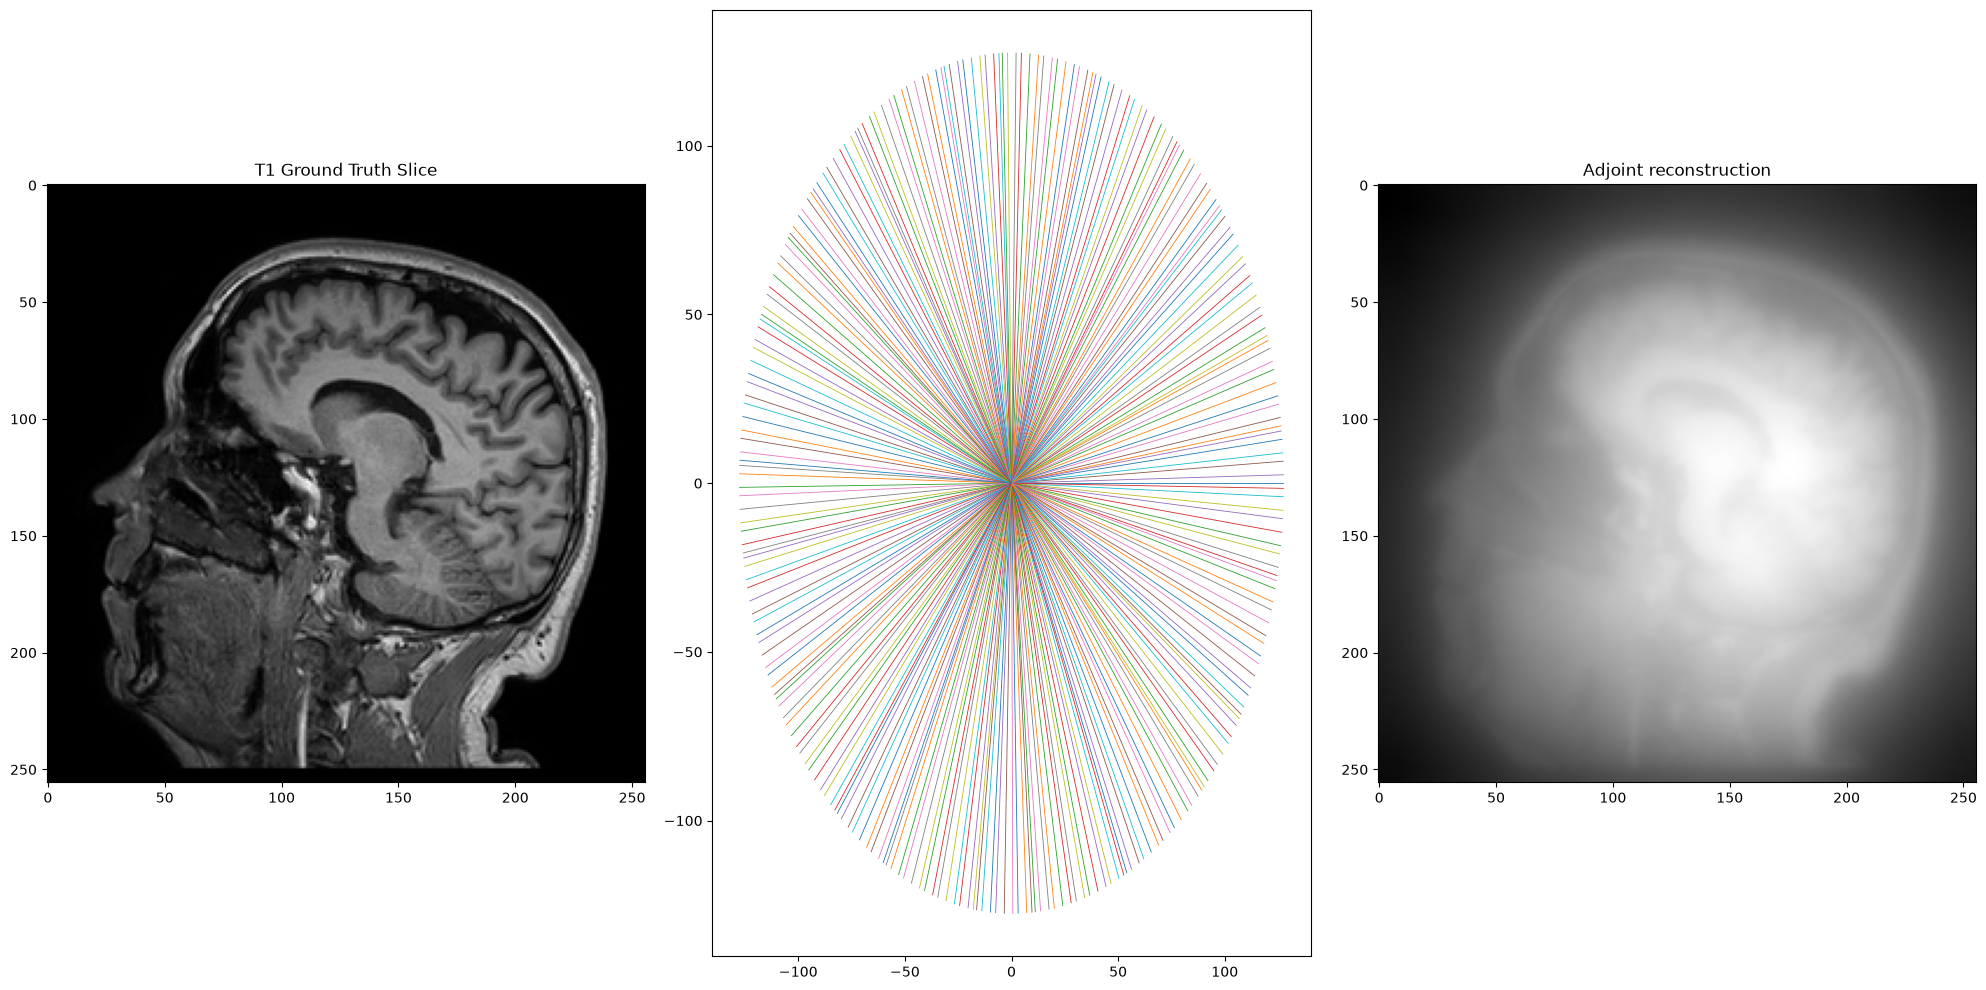

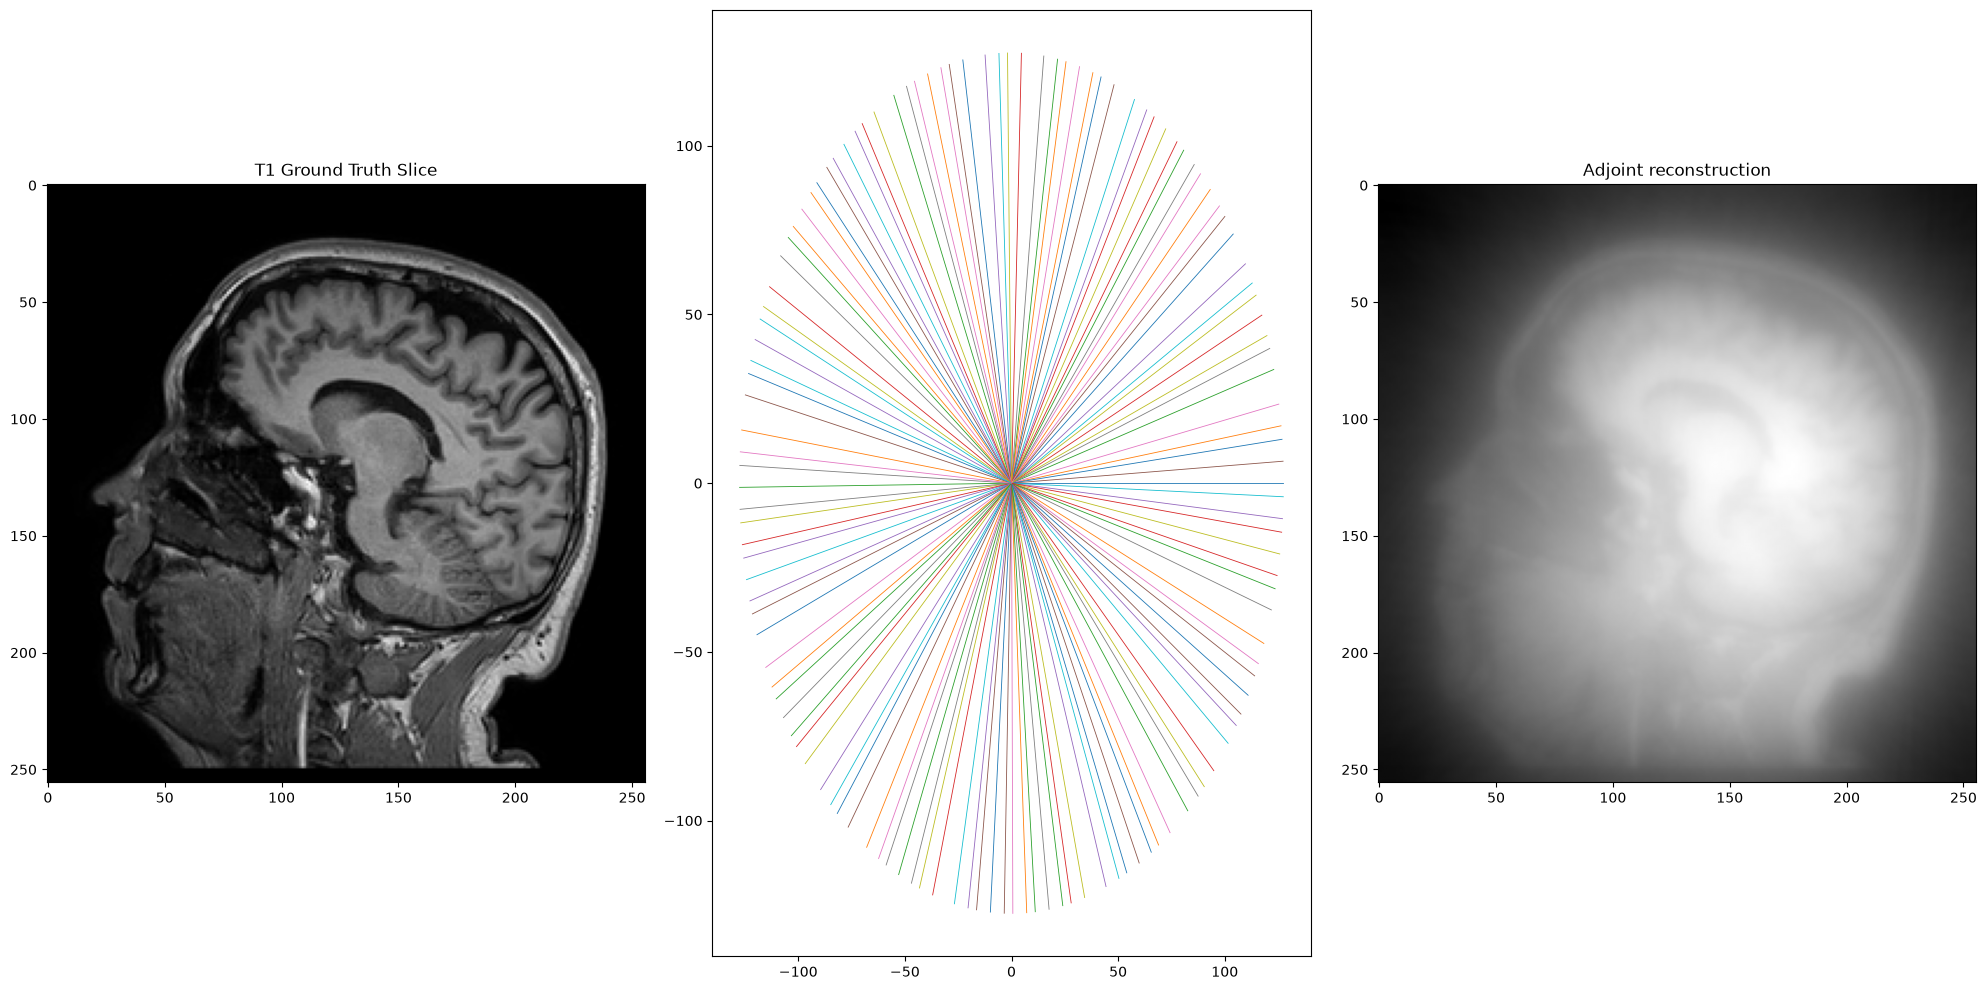

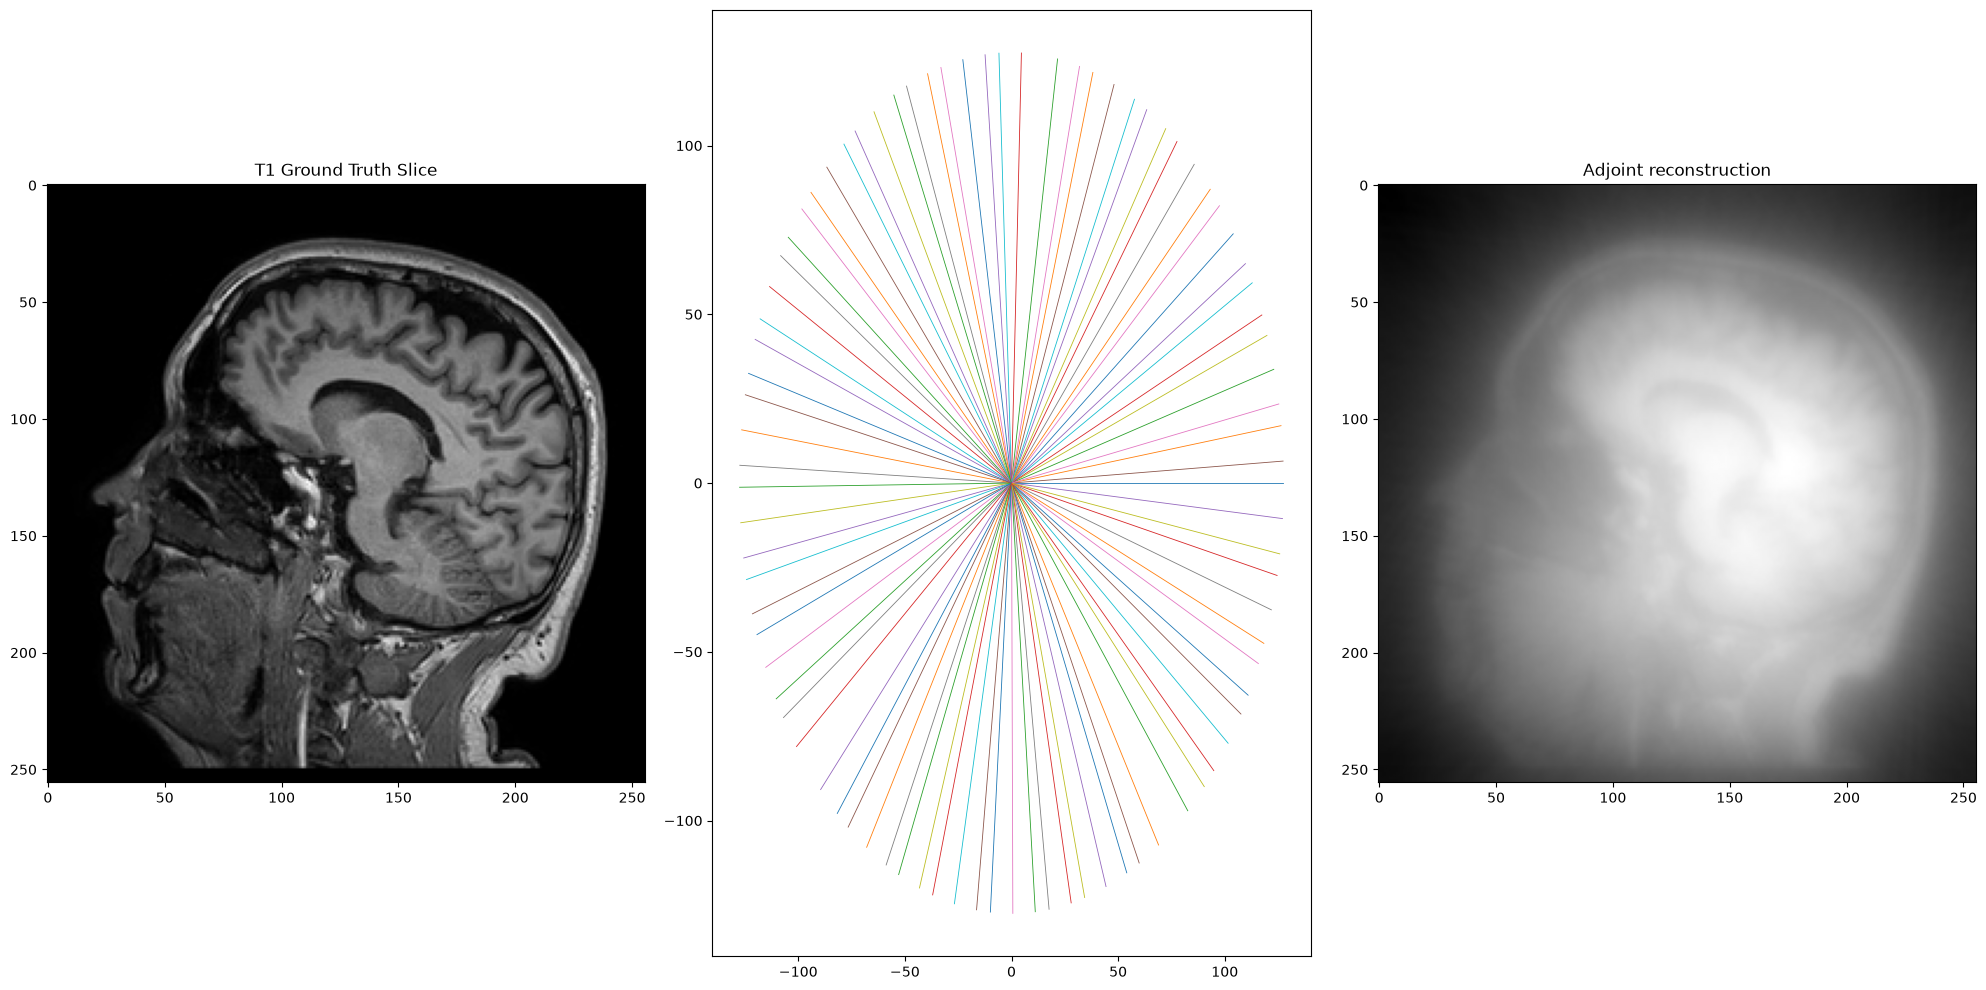

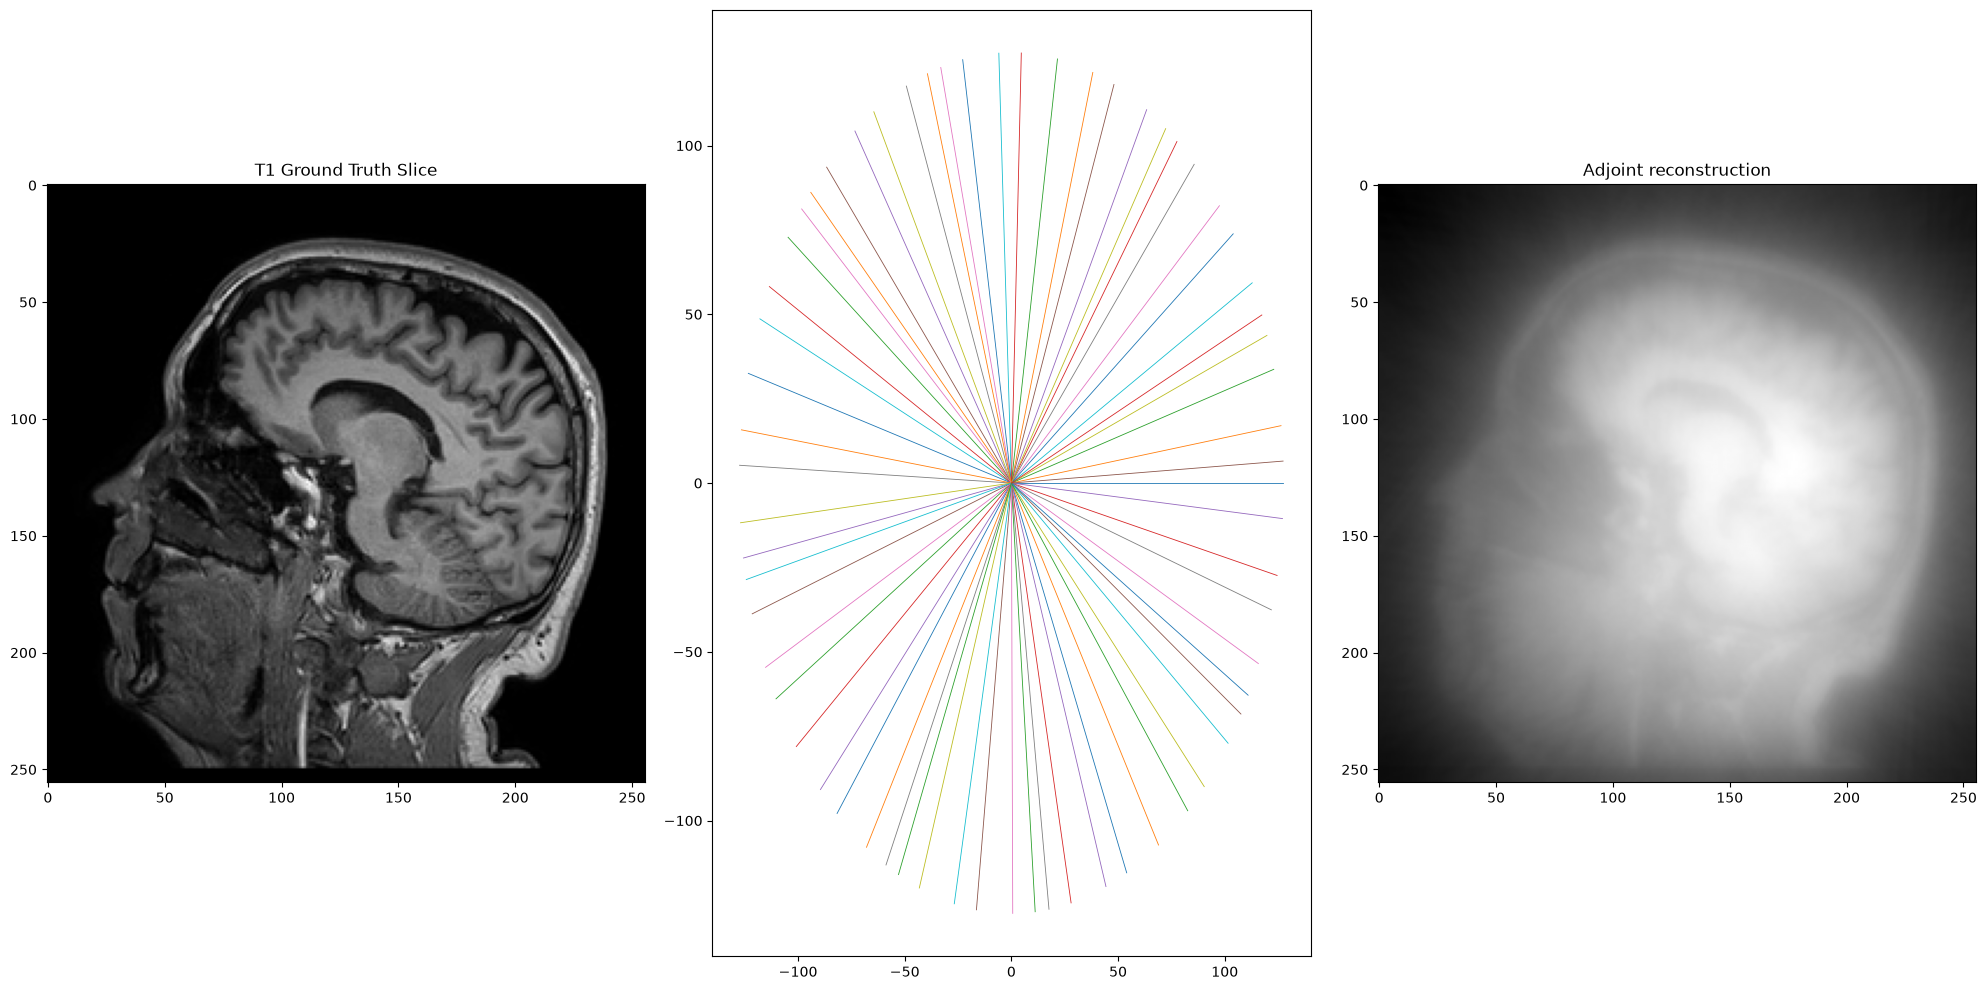

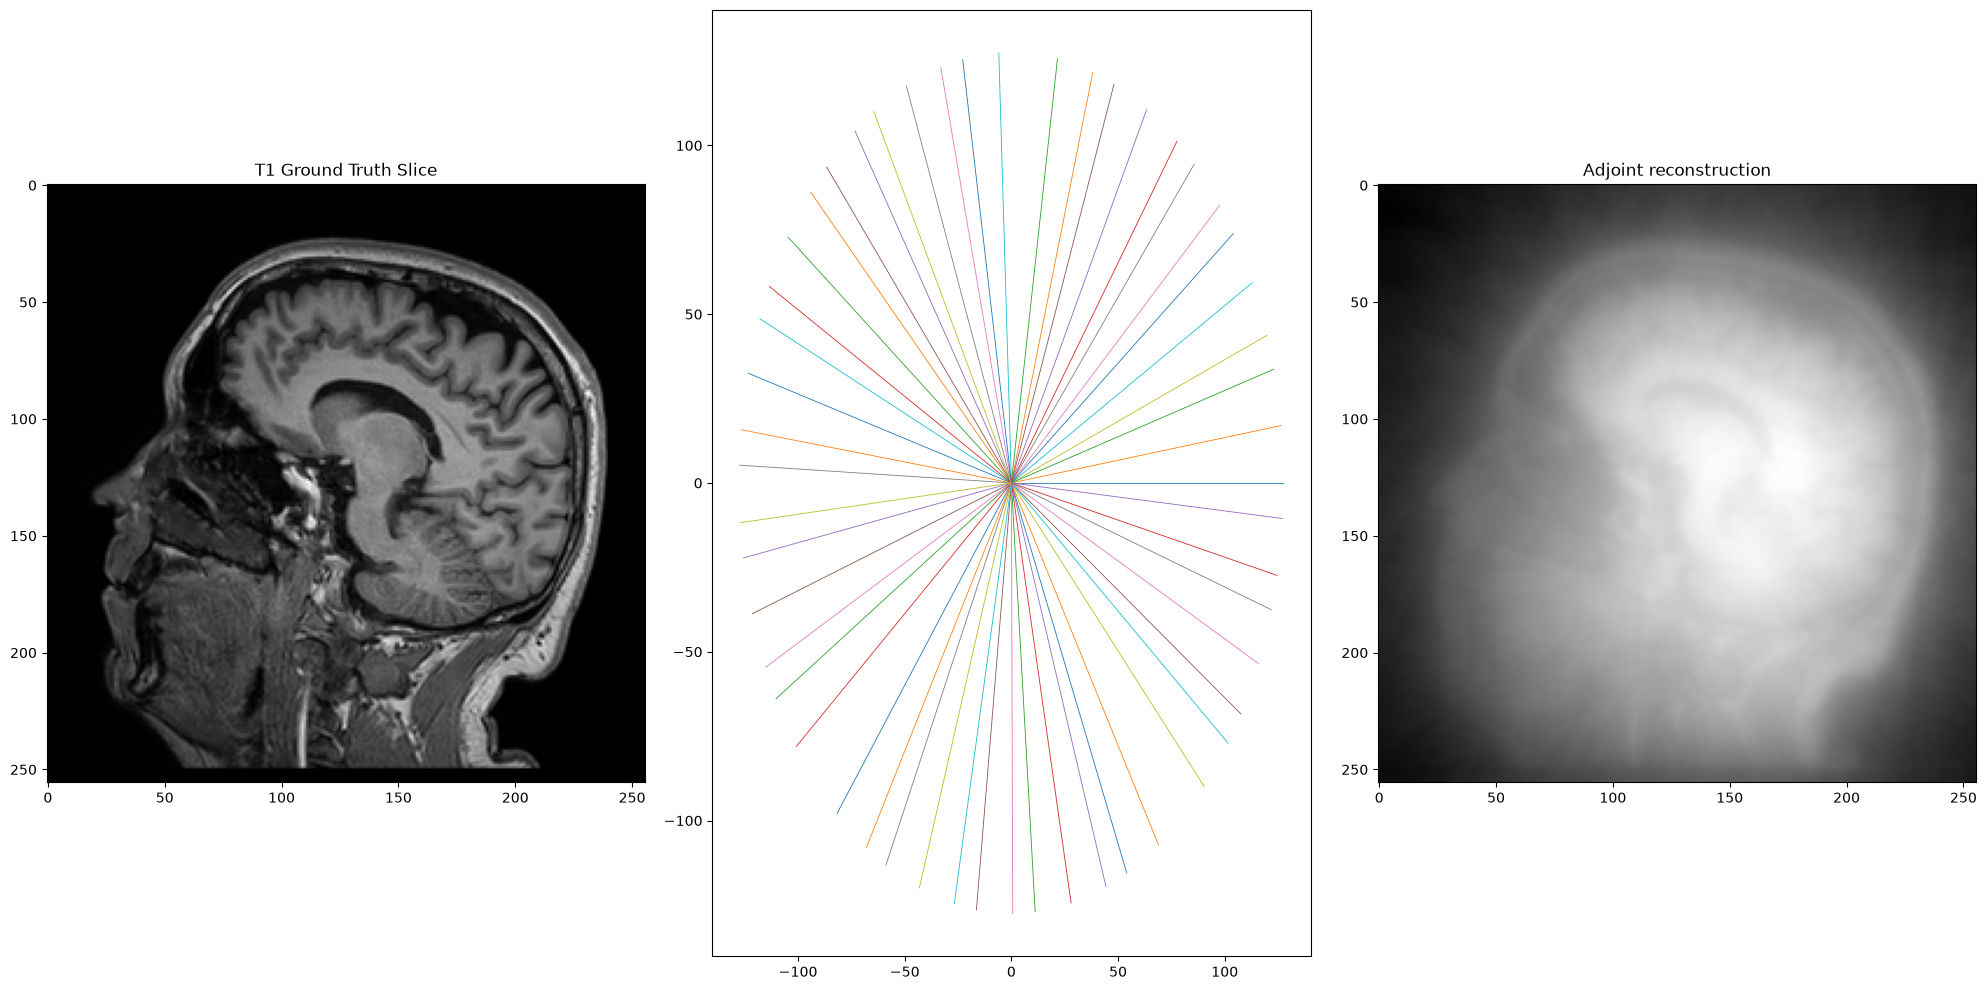

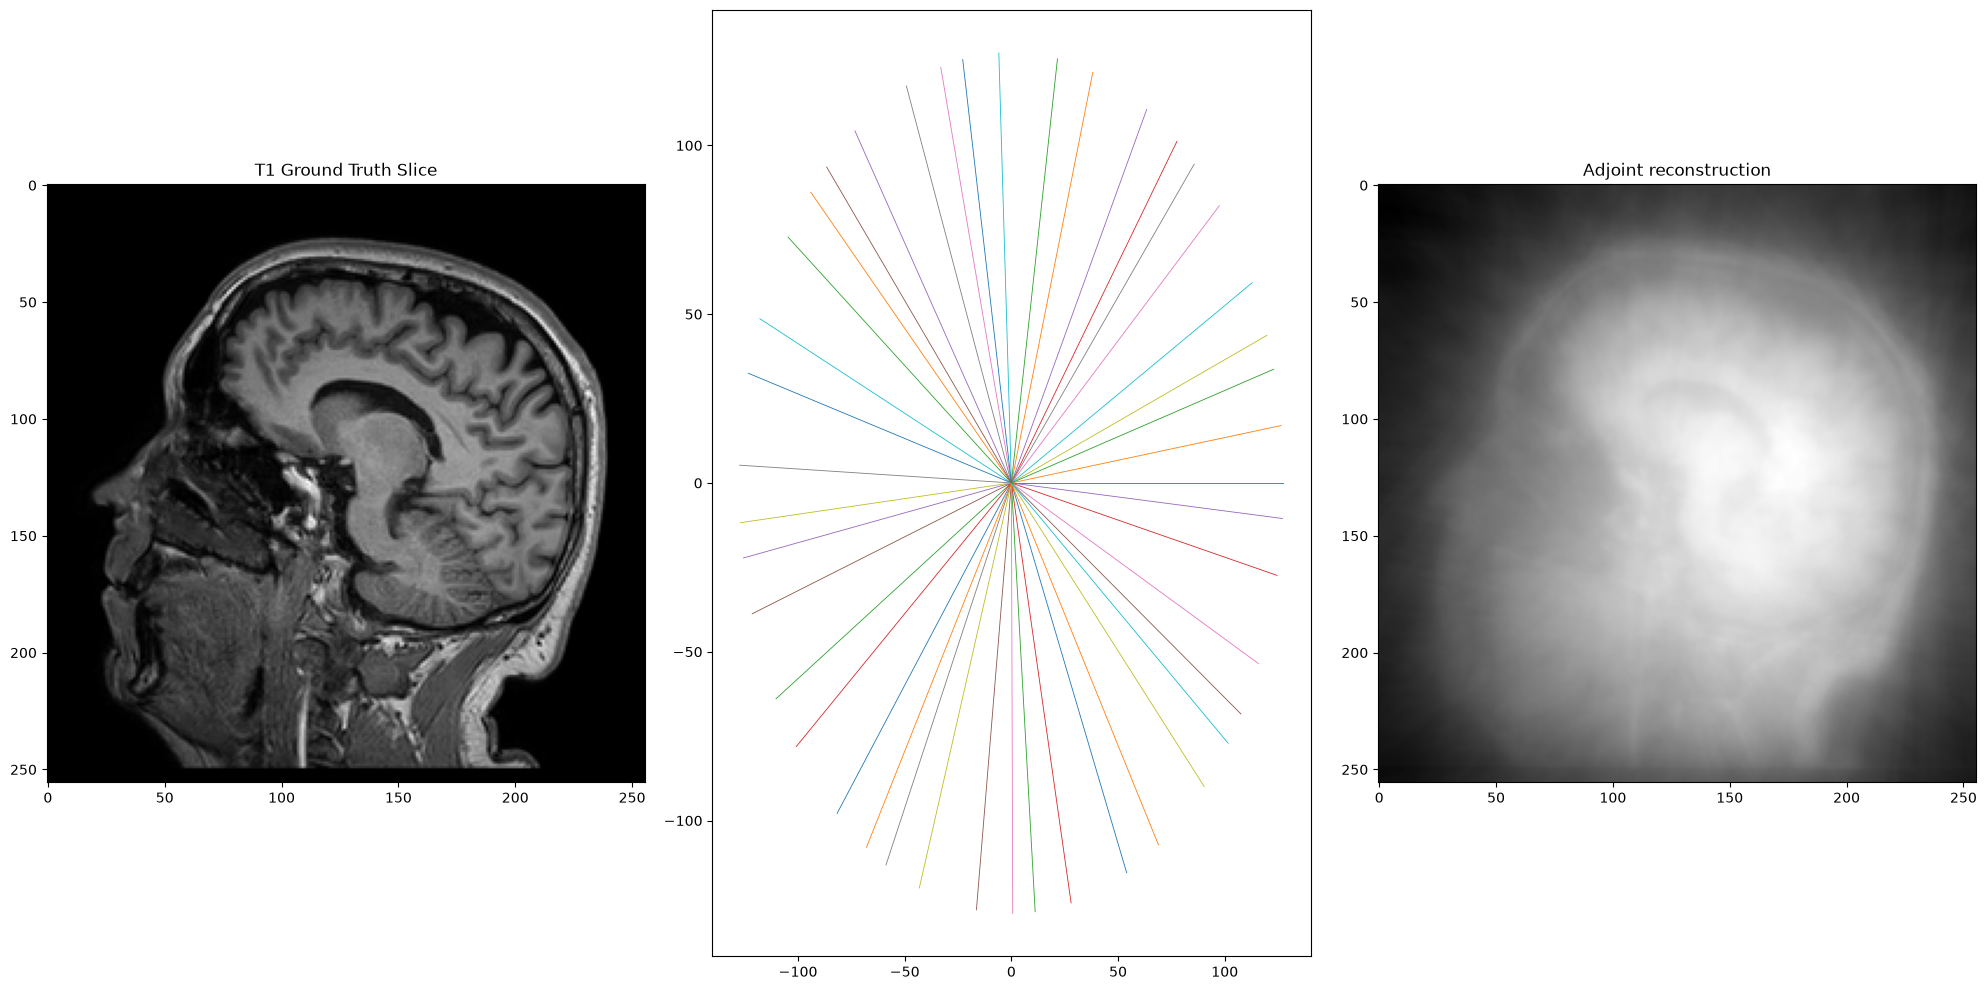

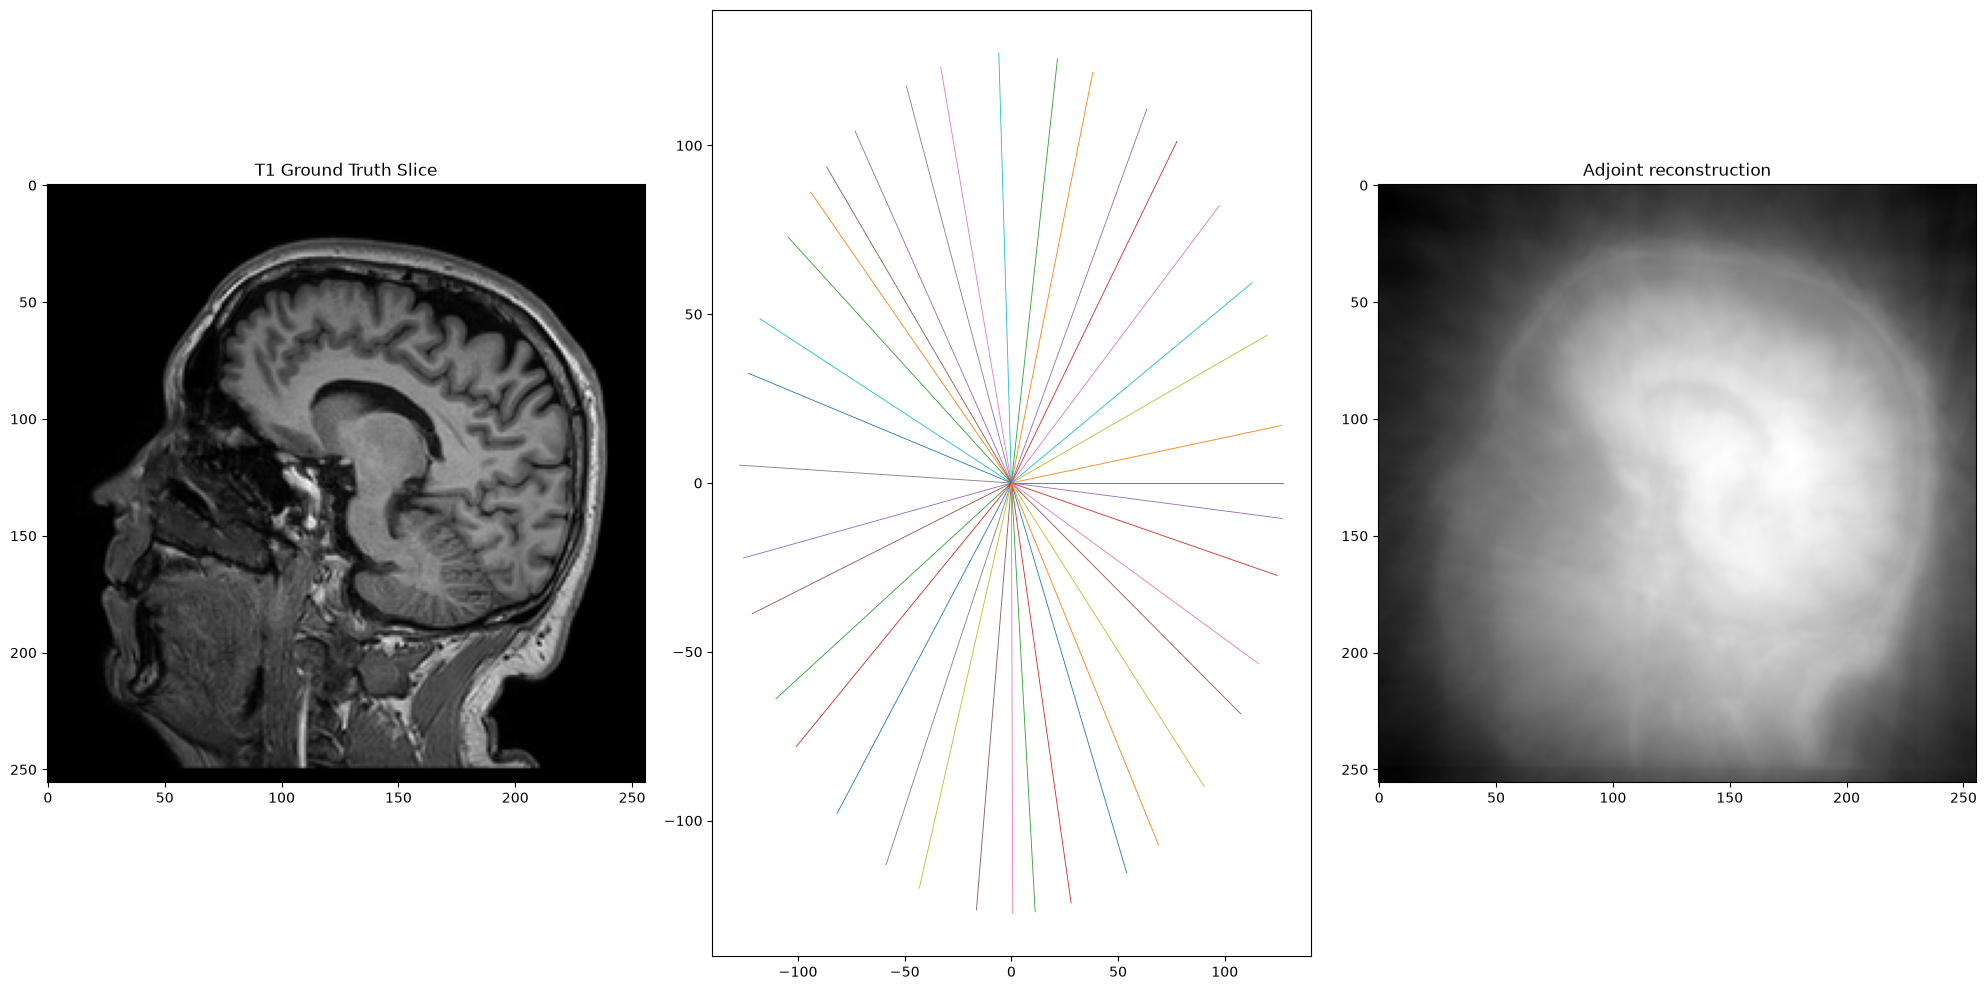

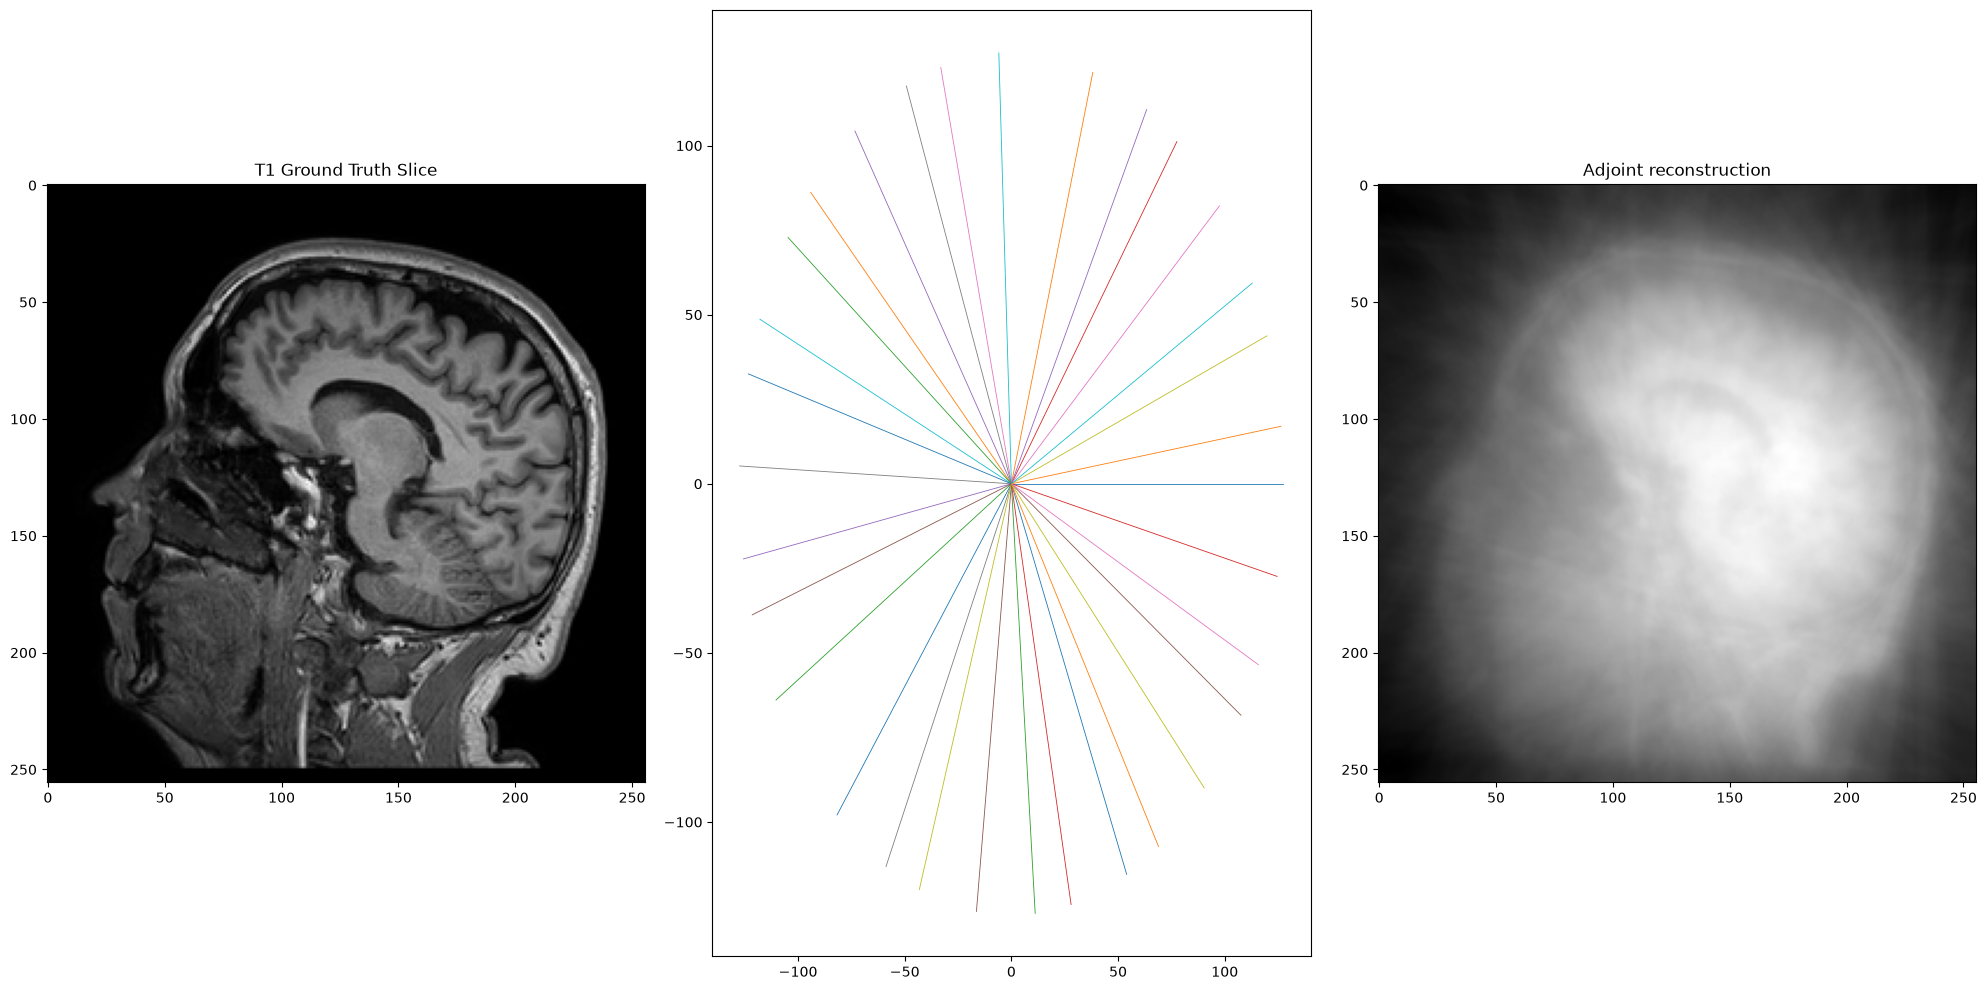

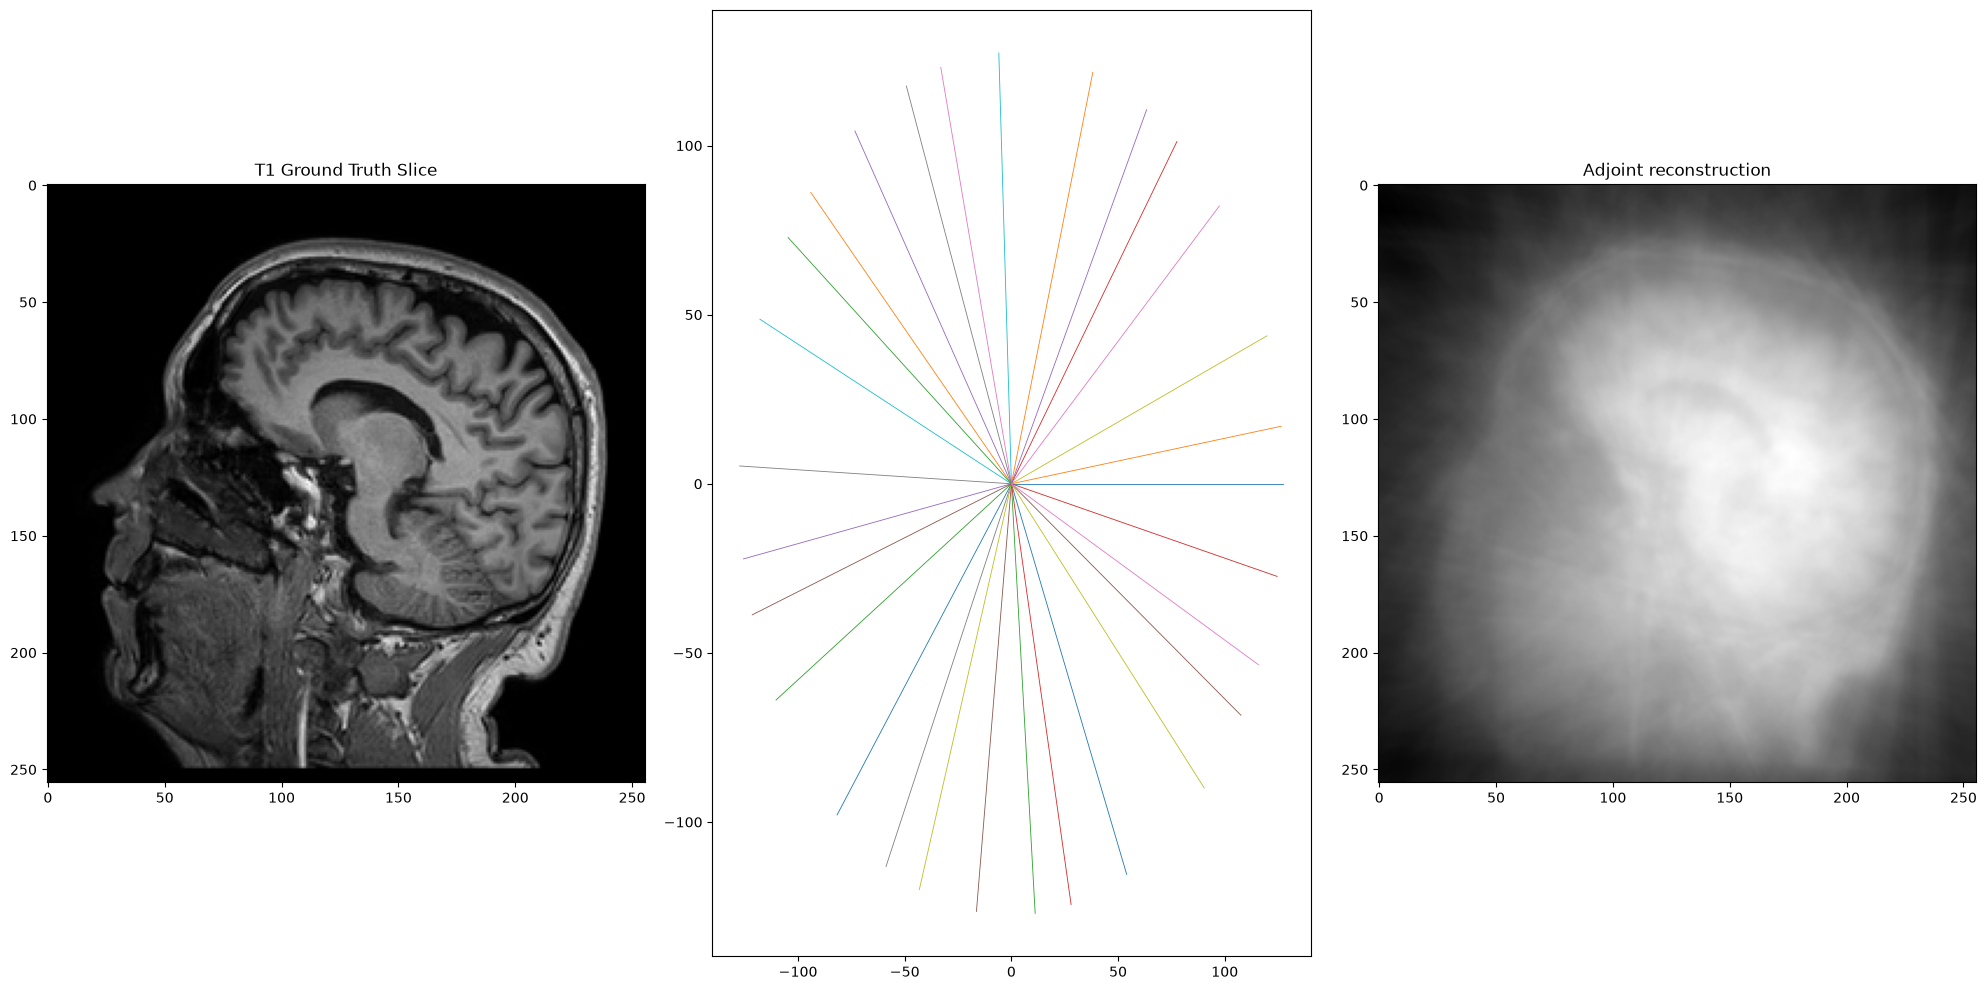

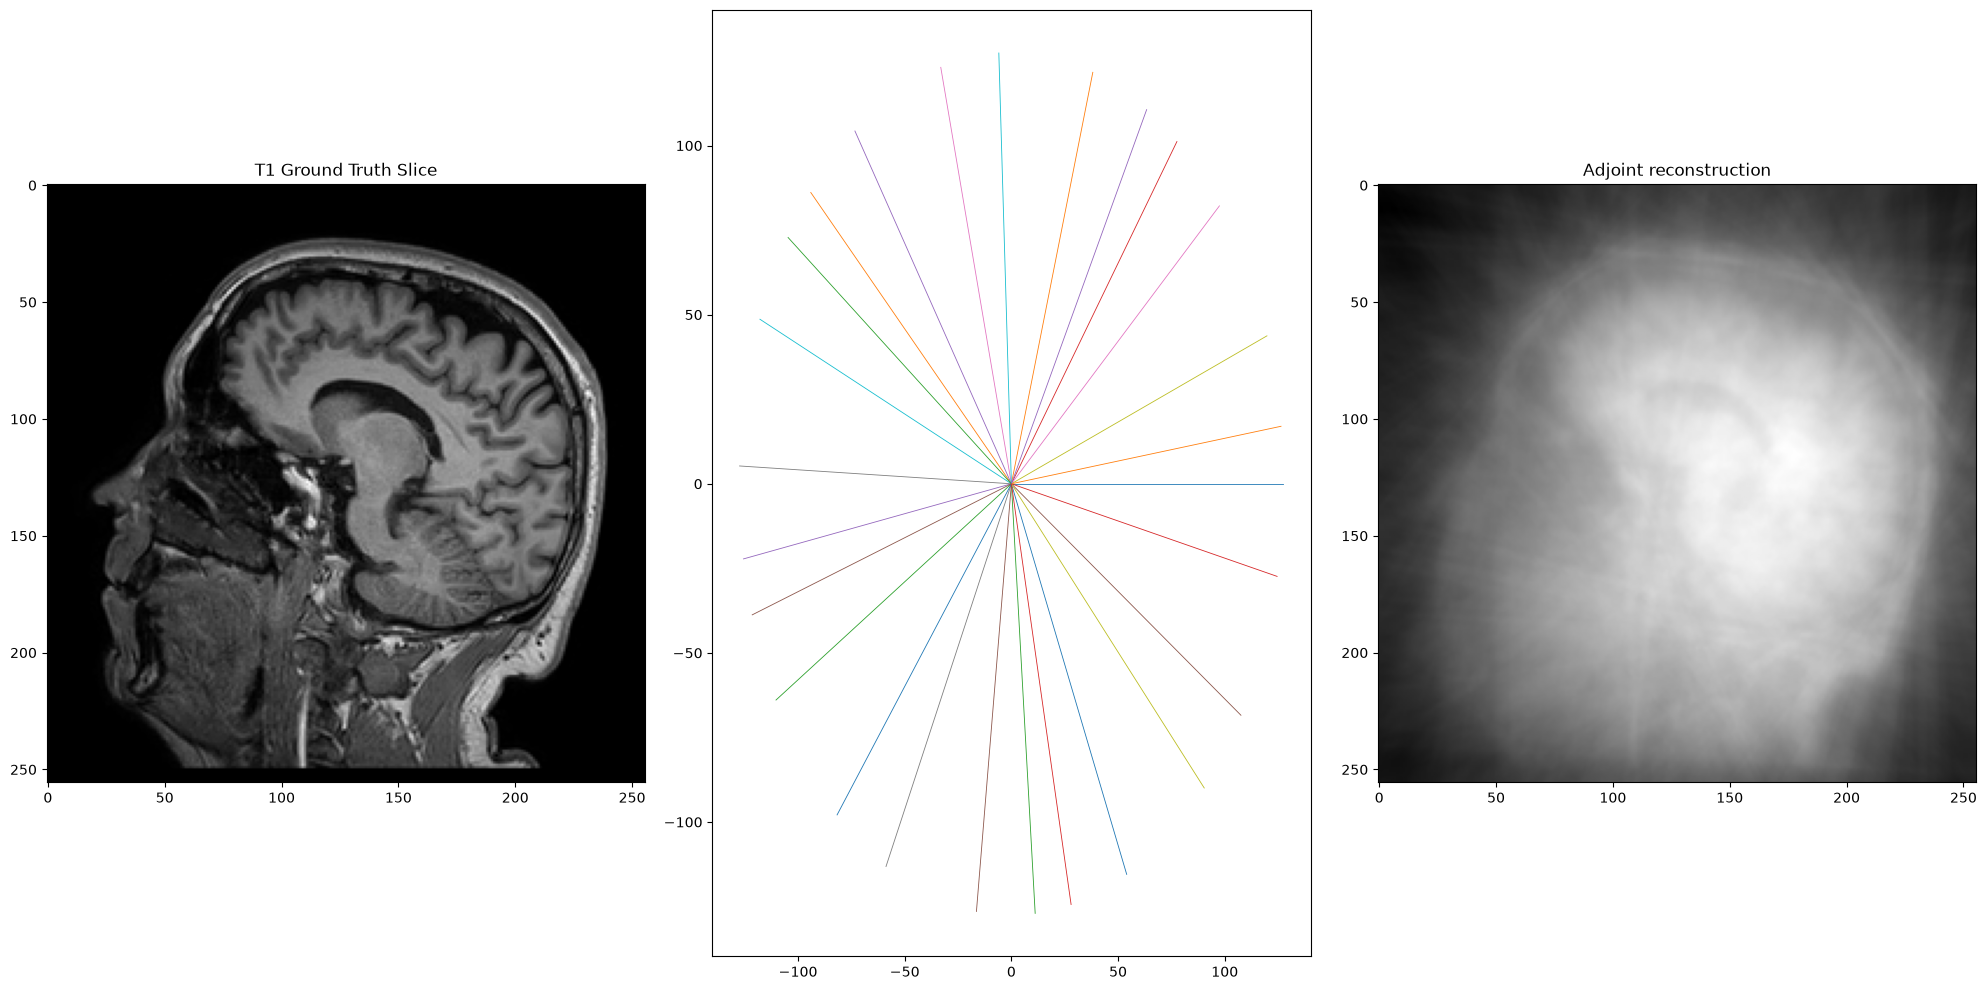

In [38]:
# Sample the k-space using the radial trajectory
k_full = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(img))) # doing the fourier transform of the image to get the full k-space data
j=1
time_arr = []
for sampling_coords in sampling_coords_arr:
    time_now = time.time()
    nufft = sigpy.linop.NUFFT(img.shape, sampling_coords) # nufft is the operator that will sample the k-space data at the specified coordinates
    
    k_sampled = nufft * img #convolution in k-space is done with multiplication ->k-sampled are the sampled points in k-space  
    adjoint = nufft.H * k_sampled # adjoint is the reconstruction in image space
    recon = np.asarray(adjoint) # asarray is used to convert the result to a numpy array
    time_done = time.time()
    elapsed_time = time_done-time_now
    time_arr.append(elapsed_time)
    
    '''print("Sampled k-space shape:", k_sampled.shape)
    print("Reconstruction shape:", recon.shape)
    print("Max reconstructed value:", np.max(recon))'''

    fig, (ax_img, ax_traj, ax_recon) = plt.subplots(1, 3, figsize=(20, 10))  

    ax_img.imshow(np.abs(img), cmap="gray")
    ax_img.set_title("T1 Ground Truth Slice")  
    
    ax_traj.set_title("")

    for spoke in sampling_coords:
            ax_traj.plot(spoke[:, 1], spoke[:, 0], linewidth=0.6)

    ax_recon.imshow(np.abs(recon), cmap="gray")
    ax_recon.set_title("Adjoint reconstruction")
    
    plt.tight_layout()
    plt.show()
    j += 2

In [53]:
cartesian_samples = img.shape[0]*img.shape[1]
print(f"Cartesian sampling points: {cartesian_samples}")

Cartesian sampling points: 65536


In [54]:
for i in range(len(time_arr)):
    acc_fac = cartesian_samples / (sampling_coords_arr[i].shape[0] * num_acq)
    print(f"Spokes: {sampling_coords_arr[i].shape[0]}, Number of Sampling Points = {sampling_coords_arr[i].shape[0]*num_acq},Time: {time_arr[i]}, Acc Factor: {acc_fac}")
    
    

Spokes: 256, Number of Sampling Points = 65536,Time: 0.09274959564208984, Acc Factor: 1.0
Spokes: 128, Number of Sampling Points = 32768,Time: 0.04904818534851074, Acc Factor: 2.0
Spokes: 86, Number of Sampling Points = 22016,Time: 0.03155398368835449, Acc Factor: 2.9767441860465116
Spokes: 64, Number of Sampling Points = 16384,Time: 0.027044057846069336, Acc Factor: 4.0
Spokes: 52, Number of Sampling Points = 13312,Time: 0.026540756225585938, Acc Factor: 4.923076923076923
Spokes: 43, Number of Sampling Points = 11008,Time: 0.01952338218688965, Acc Factor: 5.953488372093023
Spokes: 37, Number of Sampling Points = 9472,Time: 0.019021987915039062, Acc Factor: 6.918918918918919
Spokes: 32, Number of Sampling Points = 8192,Time: 0.015021562576293945, Acc Factor: 8.0
Spokes: 29, Number of Sampling Points = 7424,Time: 0.015581846237182617, Acc Factor: 8.827586206896552
Spokes: 26, Number of Sampling Points = 6656,Time: 0.014026880264282227, Acc Factor: 9.846153846153847
